#### Faz 1, Adım 1: Günlük gelir serisini çıkar

notebooks/01_daily_revenue.ipynb dosyasında:

- orders ve order_items tablolarını oku, birleştir.
- order_purchase_timestamp bazında günlük gelir serisi oluştur.
- Seriyi çiz. Seyrek başı ve sonu bul, kırpma tarihlerini belirle.

In [1]:
import pandas as pd # pandas kütüphanesini içe aktarıyoruz.
try:
    orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
    orders_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
except FileNotFoundError as e:
    print(f"Dosya bulunamadı: {e}")
finally:
    print("Kod bloğu çalıştırıldı.")

Kod bloğu çalıştırıldı.


In [2]:
orders.head() # orders tablosuna genel bakış.

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
orders['order_status'].value_counts() # farklı sipariş durumlarını ve sayılarını görelim.

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

- delivered (96.478): Siparişin başarılı bir şekilde alıcıya teslim edildiğini ve sürecin tamamlandığını belirtir.
- shipped (1.107): Ürünün satıcı tarafından kargoya verildiğini ve şu an dağıtım/nakliye aşamasında olduğunu gösterir.
- canceled (625): Müşteri veya satıcı tarafından herhangi bir aşamada iptal edilmiş siparişleri ifade eder.
- unavailable (609): Sipariş sonrasında ürünün stokta bulunamaması gibi nedenlerle tedarik edilemediğini gösterir.
- invoiced (314): Siparişin faturasının kesildiğini ancak henüz kargo firmasına teslim edilmediğini belirtir.
- processing (301): Ödemesi onaylanan siparişin satıcı tarafından hazırlanma ve paketlenme aşamasında olduğunu gösterir.
- created (5): Siparişin sistemde yeni oluşturulduğunu ancak henüz ödeme veya onay sürecine geçmediğini ifade eder.
- approved (2): Sipariş ödemesinin sistem tarafından onaylandığını ve bir sonraki aşamaya geçmeyi beklediğini belirtir.

In [5]:
orders_items.head() # orders_items tablosuna genel bakış.

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [4]:
orders.info() # orders tablosunun veri tiplerini ve eksik değerlerini görelim.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [5]:
orders_items.info() # orders_items tablosunun veri tiplerini ve eksik değerlerini görelim.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


### Orders

1) order_id: unique identifier of the order.
2) customer_id: key to the customer dataset. Each order has a unique customer_id.
3) order_status: Reference to the order status (delivered, shipped, etc).
4) order_purchase_timestamp: Shows the purchase timestamp.
5) order_approved_at: Shows the payment approval timestamp.
6) order_delivered_carrier_date: Shows the order posting timestamp. When it was handled to the logistic partner.
7) order_delivered_customer_date: Shows the actual order delivery date to the customer.
8) order_estimated_delivery_date: Shows the estimated delivery date that was informed to customer at the purchase moment.

### Order Items

1) order_id: order unique identifier
2) order_item_id: sequential number identifying number of items included in the same order.
3) product_id: product unique identifier
4) seller_id: seller unique identifier
5) shipping_limit_date: Shows the seller shipping limit date for handling the order over to the logistic partner.
6) price: item price
7) freight_value :item freight value item (if an order has more than one item the freight value is splitted between items)

**Not**: timestamp ifadesi türkçede zaman damgası anlamına gelir.


Öncelikle tabloları order_id üzerinden birleştiriyorum. Ardından birleşen tablodan gerekli filtreleri uygulayarak order_id, order_purchase_timestamp, price ve order_status kolonlarını seçiyorum. En sonunda date'e göre günlük gruplayarak grafik çizip, kırpma tarihlerini belirleyip sonuçları sana aktarıyorum.

In [6]:
merged_df = pd.merge(left = orders, right = orders_items, on = 'order_id') # orders ve orders_items tablolarını order_id üzerinden birleştiriyoruz.
merged_df.head() # birleştirilen tabloya göz atıyoruz.

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [8]:
filtered_df = merged_df[merged_df['order_status'].isin(['delivered', 'shipped', 'invoiced', 'processing', 'approved'])][['order_id', 'order_status', 'order_purchase_timestamp', 'price']] # filtreleme ve sütun seçme bloğu
filtered_df.head() # filtrelenen df'e genel bakış atalım kontrol amaçlı.

,order_id,order_status,order_purchase_timestamp,price
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,19.90


In [9]:
filtered_df['price'].describe() # price sütununun istatistiksel özetini görelim. Price değeri < 0 olamaz.

count    112101.000000
mean        120.377166
std         182.637401
min           0.850000
25%          39.900000
50%          74.900000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [10]:
filtered_df['order_status'].unique() # filtrelenen df'deki farklı order_status değerlerini kontrol edelim. Sonuçta sadece delivered, shipped, invoiced, processing ve approved değerleri olmalı.

array(['delivered', 'invoiced', 'shipped', 'processing', 'approved'],
      dtype=object)

In [11]:
filtered_df['order_purchase_timestamp'].dtype

dtype('O')

Tarihleri kronolojik (eskiden yeniye) sıraya dizmek için, Saati, günü veya ayı ayıklamak için; Örneğin "bana sadece günleri veya ayları grupla" demek, ayrıca grafik çizildiğinde zaman ekseni (X ekseni) birbirine girmemesi ve hatalı bir çizim olmaması için, order_purchase_timestamp sütununu datetime tipine dönüştüreceğiz.

In [12]:
filtered_df['order_purchase_timestamp'] = pd.to_datetime(filtered_df['order_purchase_timestamp'], format='%Y-%m-%d %H:%M:%S') # order_purchase_timestamp sütununu datetime tipine çeviriyoruz.
print(filtered_df['order_purchase_timestamp'].dtype)# dönüşümün başarılı olup olmadığını kontrol edelim.

datetime64[ns]


### Sonuç
Dönüşüm başarılı.

**Yukarıdaki sembollerin anlamı**:

* %Y: 4 haneli yıl (2017)
* %m: 2 haneli ay (10)
* %d: 2 haneli gün (02)
* %H: 24 saatlik formatta saat (10)
* %M: Dakika (56)
* %S: Saniye (33)


### Artık gün bazlı toplam gelir grafiğimizi çizebiliriz.

In [13]:
gunluk_gelir = filtered_df.groupby(filtered_df['order_purchase_timestamp'].dt.date)['price'].sum()
# dt.date ifadesi tarihi saat, dakika ve saniye olmadan sadece tarih olarak alır. Grafiğin bozulmaması için bunu yapıyoruz.
gunluk_gelir.head() # gruplama sonucumuza göz atalım

order_purchase_timestamp
2016-09-04      72.89
2016-09-15     134.97
2016-10-03     441.98
2016-10-04    9571.16
2016-10-05    6856.56
Name: price, dtype: float64

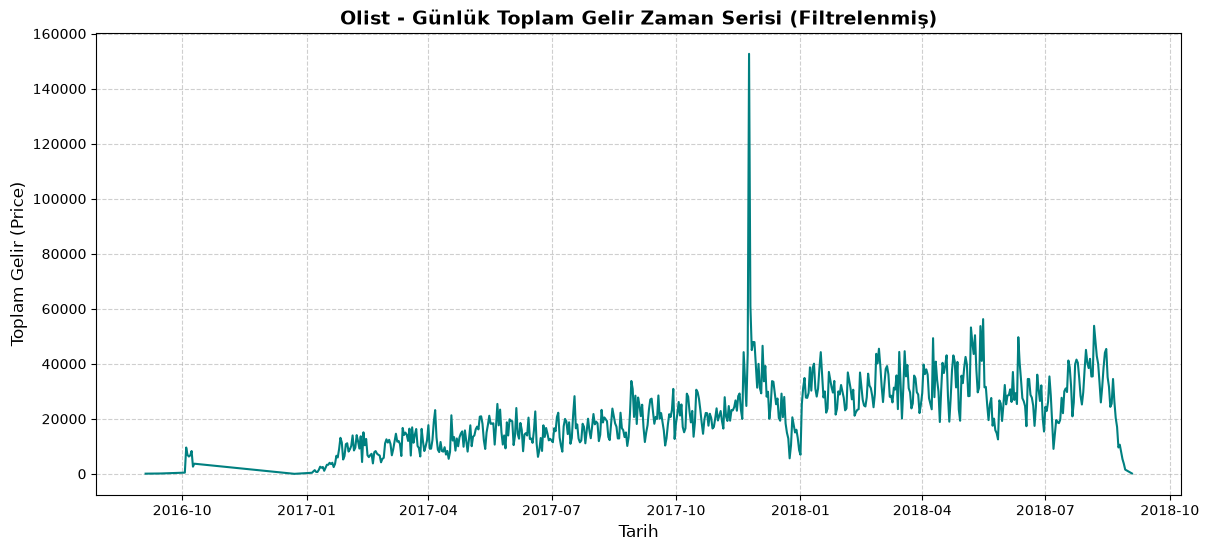

In [17]:
## artık grafiğimizi çizdirebiliriz.
import matplotlib.pyplot as plt # matplotlib kütüphanesini içe aktarıyoruz.
import seaborn as sns # seaborn kütüphanesini içe aktarıyoruz.
import numpy as np # numpy kütüphanesini içe aktarıyoruz.
plt.figure(figsize = (14, 6)) # grafiğin genişlik (14) ve yükseklik (6) değerlerini ayarlıyoruz.
plt.plot(gunluk_gelir.index, np.array(gunluk_gelir.values), color = 'teal', linewidth = 1.5) # x eksenine tarihleri, y eksenine gelir değerlerini yerleştiriyoruz.

plt.title('Olist - Günlük Toplam Gelir Zaman Serisi (Filtrelenmiş)', fontsize=14, fontweight='bold') # başlık ekliyoruz.
plt.xlabel('Tarih', fontsize=12) # x eksenine başlık ekliyoruz.
plt.ylabel('Toplam Gelir (Price)', fontsize=12) # y eksenine başlık ekliyoruz.
plt.grid(True, linestyle='--', alpha=0.6) # Arkaya hafif kılavuz çizgileri ekliyoruz.

plt.show() # grafiği ekranda göstermek için show fonksiyonunu kullanmak zorundayız.

Aşağıdaki kod bloğunda, veriyi nereden kırpacağımıza karar vermek için **ay bazlı**, toplam sipariş adedi ve farklı sipariş verilen günlerin sayısını çıkaracağız.

In [19]:
filtered_df['year_and_month'] = filtered_df['order_purchase_timestamp'].dt.to_period('M') # öncelikle filtrelenmiş dataframe'e sadece yıl-ay formatında yeni bir sütun ekliyoruz.
# to_period('M') fonksiyonundaki 'M' (Month) harfi, Pandas'a "Bu tarihin saatini, dakikasını ve gününü çöpe at; bana sadece Yıl ve Ay bilgisini bırak" talimatını verir.
filtered_df['year_and_month'].head() # yeni sütuna göz atalım.

0    2017-10
1    2018-07
2    2018-08
3    2017-11
4    2018-02
Name: year_and_month, dtype: period[M]

In [20]:
# Yıl-Ay bazlı gruplama ve istatistiksel özetleme işlemi yapacağız. Örneğin 2017 Ocak, 2017 Şubat vs.
yil_ay_bazli_gruplama = filtered_df.groupby('year_and_month')['order_purchase_timestamp'].agg(
    farkli_siparis_gun_sayisi = lambda x: x.dt.date.nunique(), # farklı sipariş gün sayısı
    toplam_siparis_sayisi = 'count', # o ay bazlı toplam sipariş sayısı
)
yil_ay_bazli_gruplama.head() # sonuçlara göz atalım.

,farkli_siparis_gun_sayisi,toplam_siparis_sayisi
year_and_month,,
2016-09,2,5
2016-10,8,342
2016-12,1,1
2017-01,27,953
2017-02,28,1936


In [21]:
# büyük resmi görmek için Yıl-Ay bazlı gruplama sonucunun tamamına bakacağız.
yil_ay_bazli_gruplama

,farkli_siparis_gun_sayisi,toplam_siparis_sayisi
year_and_month,,
2016-09,2,5
2016-10,8,342
2016-12,1,1
2017-01,27,953
2017-02,28,1936
2017-03,31,2975
2017-04,30,2660
2017-05,31,4106
2017-06,30,3571


Sonuçları incelediğimizde 2016 ayının eylül, ekim ve aralık aylarında veri eksikliğinden kaynaklanan durumları, ayrıca 2018 yılının eylül ayındaki veri eksikliğini sonuçlardan çıkaracağız. Amacımız satışların normal düzeyde seyrettiği yerleri almak, sistemin açılmadığı, verilerin eksik olduğu zamanları almak istemiyoruz. Bizim için anomali sistemin normal şekilde çalıştığı ancak belirli nedenlerle satışların çok az veya çok fazla günleri tespit etmek olacak.

In [24]:
# Ocak 2017'nin ilk 15 gününü filtreleyip gün gün gelir toplamını görelim, Ocak ayında veri eksikliğinden kaynaklanan günler var.
gunluk_gelir.index = pd.to_datetime(gunluk_gelir.index) # öncelikle tarih bilgilerini datetime tipine çeviriyoruz.
ocak_baslangic = gunluk_gelir.loc['2017-01-01':'2017-01-15']
print("--- Ocak 2017 İlk 15 Gün ---")
print(ocak_baslangic) 

--- Ocak 2017 İlk 15 Gün ---
order_purchase_timestamp
2017-01-05     396.90
2017-01-06     916.38
2017-01-07    1351.90
2017-01-08     709.58
2017-01-09     673.79
2017-01-10    1434.87
2017-01-11    2611.26
2017-01-12    2234.58
2017-01-13    2505.58
2017-01-14    1112.69
2017-01-15    2199.57
Name: price, dtype: float64


In [25]:
# Ağustos 2018'in son 15 gününü filtreleyip gün gün gelir toplamını görelim
agustos_bitis = gunluk_gelir.loc['2018-08-16':'2018-08-31']
print("\n--- Ağustos 2018 Son 15 Gün ---")
print(agustos_bitis)



--- Ağustos 2018 Son 15 Gün ---
order_purchase_timestamp
2018-08-16    35166.77
2018-08-17    31683.18
2018-08-18    24340.95
2018-08-19    25487.39
2018-08-20    34479.50
2018-08-21    26323.06
2018-08-22    20297.13
2018-08-23    17030.87
2018-08-24     9585.71
2018-08-25    10599.41
2018-08-26     8070.71
2018-08-27     5345.91
2018-08-28     3673.91
2018-08-29     1546.04
Name: price, dtype: float64


#### Kırpma tarihlerini tespit ederken kullanılabilecek 2 yöntem

1) Gerçek anomali ani ve geçicidir, sonra toparlanır. Veri artefaktı ise sürekli ve tek yönlüdür: üst üste düşer ya da yükselir ve geri dönmez.
2) Şüphedeysen fazla kırp. 2 gün veri kaybetmenin maliyeti sıfır, sistemin sahte bir alarm üretmesinin maliyeti yüksek.

### Zaman Serisi Kırpma (Data Trimming) Analizi ve Gerekçesi

Bu projede temel amacımız, sistem genelindeki **KPI'ların beklenen davranıştan saptığı günleri (gerçek anomalileri)** otomatik olarak tespit etmektir. Bu süreçte en kritik ayrım şudur: **Veri eksikliği/kayıt hataları birer anomali değildir.** Modelleme aşamasında sistemin normal gidişatı (baseline) doğru öğrenmesi için, veri setinin başında ve sonunda yer alan veri gürültülerini (artefaktları) gün bazında inceleyerek temizlememiz gerekmektedir. 

Yapılan gün bazlı mikroskop incelemesi sonucunda `config.yaml` dosyasına işlenecek kesin kırpma tarihleri ve analitik gerekçeleri şu şekildedir:

*   **`start_date: "2017-01-11"`**
    *   **Gerekçe:** 2016 yılının son aylarındaki sistemsel veri eksikliğinin ardından, Ocak 2017'nin ilk günlerinde (5-10 Ocak arası) veri kaydı stabil değildir ve gelir seviyesi yeni normuna oturmamıştır; belirsizlik durumunda güvenli tarafta kalma prensibi uyarınca, serinin kalıcı olarak 2.000 - 2.600 bandına yükselip istikrarlı tırmanışına başladığı **11 Ocak 2017** tarihi başlangıç noktası olarak seçilmiştir.
*   **`end_date: "2018-08-21"`**
    *   **Gerekçe:** 16-21 Ağustos 2018 tarihleri arasında günlük gelir 24k - 35k bandında normal seyrini sürdürürken, 22 Ağustos'tan itibaren geri dönüşü olmayan, sürekli ve tek yönlü bir düşüş trendi (20k → 17k → 9.5k → 1.5k) başlamıştır; bu durum gerçek bir pazar durgunluğu değil, veri kaydının/toplanmasının sona ermesinden kaynaklanan sistemsel bir artefakt olduğundan, veri seti **21 Ağustos 2018** gün sonu itibarıyla kesilmiştir.

Bu yapısal temizlik sayesinde fiyat, ödeme, sipariş hacmi ve teslimat gibi izleyeceğimiz tüm KPI'larda sahte alarmların (false positives) önüne geçilmiş ve modelin sadece operasyonel ve sistemsel gerçek sapmaları yakalaması garantilenmiştir.